# Levee Detection from Sentinel-1 SAR
## Feature Engineering → Training Data → XGBoost

**Stack:**
- Raster I/O: GDAL directly (`osgeo.gdal`)
- Vector I/O: GeoPandas + pyogrio
- Texture: scikit-image GLCM
- Model: XGBoost

**Expected input:**
- Preprocessed Sentinel-1 GeoTIFFs: sigma0 VV and VH, linear units, EPSG:2180, 10m
- pyroSAR output naming: `S1A__IW___A_YYYYMMDDTHHMMSS_VV_grd_elp.tif`
- BDOT10k GeoPackage with layer `OT_BUZM_L`

**Install dependencies:**
```
pip install numpy geopandas pyogrio scikit-image xgboost scikit-learn matplotlib tqdm
```

In [1]:
import sys
import torch
import numpy as np

print(f'Python      : {sys.version.split()[0]}')
print(f'PyTorch     : {torch.__version__}')
print(f'NumPy       : {np.__version__}')
print()

# ── CUDA availability ─────────────────────────────────────────────────────────
cuda_ok = torch.cuda.is_available()
print(f'CUDA available  : {cuda_ok}')

if cuda_ok:
    print(f'CUDA version    : {torch.version.cuda}')
    print(f'cuDNN version   : {torch.backends.cudnn.version()}')
    print(f'GPU count       : {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  [{i}] {props.name}')
        print(f'      VRAM       : {props.total_memory / 1e9:.1f} GB')
        print(f'      Compute    : {props.major}.{props.minor}')
        print(f'      MP count   : {props.multi_processor_count}')

    # Functional test: allocate tensor, run matmul on GPU
    print()
    print('Running functional GPU test...')
    try:
        a = torch.rand(1024, 1024, device='cuda')
        b = torch.rand(1024, 1024, device='cuda')
        c = torch.mm(a, b)
        torch.cuda.synchronize()
        print(f'  Matmul 1024x1024 : OK  (result shape {list(c.shape)})')
        del a, b, c
        torch.cuda.empty_cache()
        print('  CUDA environment : OK')
    except Exception as e:
        print(f'  CUDA functional test FAILED: {e}')
else:
    print()
    print('WARNING: CUDA not available — pipeline will run on CPU (much slower).')
    print('Check:')
    print('  1. nvidia-smi  — is the GPU visible to the OS?')
    print('  2. torch.version.cuda matches installed pytorch-cuda package')
    print(f'     torch.version.cuda = {torch.version.cuda}')


Python      : 3.12.13
PyTorch     : 2.10.0
NumPy       : 2.4.3

CUDA available  : True
CUDA version    : 13.0
cuDNN version   : 92000
GPU count       : 1
  [0] NVIDIA RTX A4000
      VRAM       : 17.2 GB
      Compute    : 8.6
      MP count   : 48

Running functional GPU test...
  Matmul 1024x1024 : OK  (result shape [1024, 1024])
  CUDA environment : OK


---
## Section 0 — Configuration

In [4]:
from pathlib import Path

# ── Input directories ──────────────────────────────────────────────────────
# pyroSAR output directories — separate VV and VH GeoTIFFs per scene
SNAP_RASTER = r"B:\01_Projects\154_Poland_Flood_v3\01_MD\01_HAZARD\00_GIS\01_SnapRaster\SnapRaster_PL_10m_2180.tif"
ASC_DIR  = Path(r'D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\sentinel1_data\processed_selected\ascending')
DESC_DIR = Path(r'D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\sentinel1_data\processed_selected\descending')

# BDOT10k GeoPackage
BDOT10K_PATH = Path(r'D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\levees_selection\OT_BUZM_L_Poland_files_selected.gpkg')

# AOI GeoPackage — defines the area of interest for clipping all rasters
AOI_PATH = Path(r'D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\AOI_Poland.gpkg')

# ── Output directory ───────────────────────────────────────────────────────
OUT_DIR = Path(r'D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Coordinate system ──────────────────────────────────────────────────────
EPSG       = 2180    # PL-1992 — consistent with BDOT10k
PIXEL_SIZE = 10.0   # metres

# ── GLCM parameters ────────────────────────────────────────────────────────
GLCM_WINDOW = 7     # sliding window size (pixels)
GLCM_LEVELS = 64    # grey levels for quantisation
GLCM_DIST   = 1     # pixel distance for co-occurrence


# ── Levee rasterization buffer ────────────────────────────────────────────
LEVEE_BUFFER = 10.0  # metres — 1 pixel

# ── Sampling ──────────────────────────────────────────────────────────────
N_POSITIVE   = 50_000
N_NEGATIVE   = 50_000
RANDOM_STATE = 42

# ── Spatial block split ────────────────────────────────────────────────────
BLOCK_SIZE   = 256   # pixels — spatial block size for train/test split
                     # 256 px × 10 m = 2.56 km — well above SAR correlation length

print('Configuration loaded.')
print(f'  ASC_DIR  : {ASC_DIR}')
print(f'  DESC_DIR : {DESC_DIR}')
print(f'  BDOT10K  : {BDOT10K_PATH}')
print(f'  OUT_DIR  : {OUT_DIR}')

Configuration loaded.
  ASC_DIR  : D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\sentinel1_data\processed_selected\ascending
  DESC_DIR : D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\sentinel1_data\processed_selected\descending
  BDOT10K  : D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\levees_selection\OT_BUZM_L_Poland_files_selected.gpkg
  OUT_DIR  : D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02


---
## Section 1 — GDAL Utility Functions

In [3]:
import numpy as np
from osgeo import gdal, ogr

gdal.UseExceptions()


def read_band(path: Path) -> tuple:
    """
    Reads a single-band GeoTIFF using GDAL.
    Returns (array float32, geo_info dict).
    NoData pixels are replaced with np.nan.
    """
    ds = gdal.Open(str(path), gdal.GA_ReadOnly)
    if ds is None:
        raise FileNotFoundError(f'Cannot open: {path}')

    band = ds.GetRasterBand(1)
    arr  = band.ReadAsArray().astype(np.float32)

    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    geo_info = {
        'geotransform': ds.GetGeoTransform(),
        'projection':   ds.GetProjection(),
        'nrows':        ds.RasterYSize,
        'ncols':        ds.RasterXSize,
    }
    ds = None
    return arr, geo_info


def write_multiband_tiff(
    path: Path,
    arrays: list,
    band_names: list,
    geo_info: dict,
    nodata: float = -9999.0,
):
    """
    Writes a list of 2D arrays as a multiband GeoTIFF.
    LZW compressed, multi-threaded, BigTIFF if needed.
    NaN values replaced with nodata before writing.
    """
    nrows, ncols = arrays[0].shape
    nbands = len(arrays)

    driver = gdal.GetDriverByName('GTiff')
    ds = driver.Create(
        str(path), ncols, nrows, nbands, gdal.GDT_Float32,
        options=[
            'COMPRESS=LZW',
            'PREDICTOR=2',
            'NUM_THREADS=ALL_CPUS',
            'BIGTIFF=IF_SAFER',
            'TILED=YES',
        ],
    )
    ds.SetGeoTransform(geo_info['geotransform'])
    ds.SetProjection(geo_info['projection'])

    for i, (arr, name) in enumerate(zip(arrays, band_names), start=1):
        print(f'  Writing band {i}/{nbands}: {name}  ({nbands - i} remaining)')
        out = np.array(arr, dtype=np.float32, copy=True)
        out[np.isnan(out)] = nodata
        band = ds.GetRasterBand(i)
        band.WriteArray(out)
        band.SetNoDataValue(nodata)
        band.SetDescription(name)

    ds.FlushCache()
    ds = None
    print(f'  Saved: {path.name}  ({nbands} bands, {nrows}x{ncols})')


print('Utility functions defined.')

Utility functions defined.


---
## Section 1.5 — AOI Extent & Warp Target

Loads the AOI GeoPackage, extracts its bounding box, and builds
a **warp target** (extent + resolution + CRS) that will be used by
`gdal.Warp` to clip and align every input raster to the same grid.

A placeholder cell is left for applying a custom extent transformation
(e.g. snapping, buffering, or rounding via an external library).


In [8]:
import geopandas as gpd
from gis import Vector

def load_aoi_extent(aoi_path: Path, target_epsg: int = EPSG) -> dict:
    """
    Loads AOI polygon from GeoPackage and returns its bounding box
    as a dict with keys: xmin, ymin, xmax, ymax (in target CRS).
    """
    aoi = gpd.read_file(aoi_path, engine='pyogrio')
    if aoi.crs and aoi.crs.to_epsg() != target_epsg:
        aoi = aoi.to_crs(epsg=target_epsg)
    bounds = aoi.total_bounds  # (xmin, ymin, xmax, ymax)
    extent = {
        'xmin': float(bounds[0]),
        'ymin': float(bounds[1]),
        'xmax': float(bounds[2]),
        'ymax': float(bounds[3]),
    }
    return extent


aoi_extent = load_aoi_extent(AOI_PATH)
extent = float(aoi_extent['xmin']), float(aoi_extent['xmax']), float(aoi_extent['ymin']), float(aoi_extent['ymax'])
aoi_extent_snapped = Vector.align_extent_to_snap(extent, SNAP_RASTER) # [left_x, right_x, bottom_y, upper_y
aoi_extent = {
    'xmin': aoi_extent_snapped[0],
    'ymin': aoi_extent_snapped[2],
    'xmax': aoi_extent_snapped[1],
    'ymax': aoi_extent_snapped[3],
}
print(f"AOI extent: xmin={aoi_extent['xmin']:.1f}  ymin={aoi_extent['ymin']:.1f}  xmax={aoi_extent['xmax']:.1f}  ymax={aoi_extent['ymax']:.1f}")

AOI extent: xmin=420530.0  ymin=475810.0  xmax=670470.0  ymax=748550.0


In [9]:
from osgeo import osr


def warp_to_aoi(
    src_path: Path,
    aoi_path: Path,
    extent: dict,
    pixel_size: float = PIXEL_SIZE,
    target_epsg: int = EPSG,
) -> np.ndarray:
    """
    Warps a single-band GeoTIFF to the AOI extent using gdal.Warp.

    - Clips to AOI polygon (cutline) so pixels outside are NaN.
    - Aligns to the target extent and pixel size so all output
      rasters have identical dimensions.

    Returns float32 array with NaN outside the AOI.
    """
    srs = osr.SpatialReference()
    srs.ImportFromEPSG(target_epsg)
    target_srs = srs.ExportToWkt()

    warp_opts = gdal.WarpOptions(
        format='MEM',
        outputBounds=(
            extent['xmin'], extent['ymin'],
            extent['xmax'], extent['ymax'],
        ),
        xRes=pixel_size,
        yRes=pixel_size,
        dstSRS=target_srs,
        resampleAlg='near',
        cutlineDSName=str(aoi_path),
        cropToCutline=False,       # extent is already set via outputBounds
        dstNodata=np.nan,
        outputType=gdal.GDT_Float32,
    )

    ds = gdal.Warp('', str(src_path), options=warp_opts)
    if ds is None:
        raise RuntimeError(f'gdal.Warp failed for {src_path}')

    arr = ds.GetRasterBand(1).ReadAsArray().astype(np.float32)

    nodata = ds.GetRasterBand(1).GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    ds = None
    return arr


def build_aoi_geo_ref(extent: dict, pixel_size: float = PIXEL_SIZE, epsg: int = EPSG) -> dict:
    """
    Builds geo_ref dict from AOI extent — consistent grid for all rasters.
    """
    srs = osr.SpatialReference()
    srs.ImportFromEPSG(epsg)
    ncols = int(round((extent['xmax'] - extent['xmin']) / pixel_size))
    nrows = int(round((extent['ymax'] - extent['ymin']) / pixel_size))
    return {
        'geotransform': (extent['xmin'], pixel_size, 0.0,
                         extent['ymax'], 0.0, -pixel_size),
        'projection':   srs.ExportToWkt(),
        'nrows':        nrows,
        'ncols':        ncols,
    }


aoi_geo_ref = build_aoi_geo_ref(aoi_extent)
print(f'AOI grid: {aoi_geo_ref["nrows"]} x {aoi_geo_ref["ncols"]} px')
print('warp_to_aoi() ready.')


AOI grid: 27274 x 24994 px
warp_to_aoi() ready.


---
## Section 2 — Multi-temporal Averaging (Welford online algorithm)

**AOI-clipped:** Every scene is warped to the AOI extent via `gdal.Warp`
before entering the Welford accumulator. This ensures all arrays have
identical dimensions and pixels outside the AOI are masked as NaN.

**Memory-efficient:** Welford’s online algorithm processes one scene at a time.
Only 3 accumulator arrays `(nrows × ncols)` in memory.

**Cache:** Results saved to `OUT_DIR/stack_cache/`. Delete the cache
directory to force recomputation.

Averaging in **linear units** (not dB) — Jensen’s inequality.


In [10]:
import json as _json
from tqdm import tqdm

CACHE_DIR = OUT_DIR / 'stack_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

STACK_KEYS = [
    'asc_vv_mean',  'asc_vv_std',
    'asc_vh_mean',  'asc_vh_std',
    'desc_vv_mean', 'desc_vv_std',
    'desc_vh_mean', 'desc_vh_std',
]


# ── Cache I/O ─────────────────────────────────────────────────────────────────────

def save_cache(arrays: dict, geo_ref: dict):
    np.savez_compressed(CACHE_DIR / 'stacks.npz', **arrays)
    with open(CACHE_DIR / 'geo_ref.json', 'w') as f:
        _json.dump({
            'geotransform': list(geo_ref['geotransform']),
            'projection':   geo_ref['projection'],
            'nrows':        geo_ref['nrows'],
            'ncols':        geo_ref['ncols'],
        }, f, indent=2)
    print(f'Cache saved -> {CACHE_DIR}')


def load_cache() -> tuple:
    npz_path  = CACHE_DIR / 'stacks.npz'
    json_path = CACHE_DIR / 'geo_ref.json'
    if not npz_path.exists() or not json_path.exists():
        return None, None
    arrays  = dict(np.load(npz_path))
    with open(json_path) as f:
        raw = _json.load(f)
    geo_ref = {
        'geotransform': tuple(raw['geotransform']),
        'projection':   raw['projection'],
        'nrows':        raw['nrows'],
        'ncols':        raw['ncols'],
    }
    print(f'Cache loaded from {CACHE_DIR}')
    return arrays, geo_ref


def cache_is_valid() -> bool:
    npz_path  = CACHE_DIR / 'stacks.npz'
    json_path = CACHE_DIR / 'geo_ref.json'
    if not npz_path.exists() or not json_path.exists():
        return False
    with np.load(npz_path) as f:
        return all(k in f for k in STACK_KEYS)


# ── Scene collection ──────────────────────────────────────────────────────────────

def collect_scenes(directory: Path, polarization: str) -> list:
    for pattern in [
        f'*_{polarization}_sigma0-elp.tif',
        f'*_{polarization}_gamma0-elp.tif',
        f'*_{polarization}_grd_elp.tif',
        f'*{polarization}*.tif',
    ]:
        scenes = sorted(directory.glob(pattern))
        if scenes:
            return scenes
    return []


# ── Welford online stacking (AOI-clipped via gdal.Warp) ─────────────────────

def temporal_stack(
    directory: Path,
    polarization: str,
) -> tuple:
    """
    Computes pixel-wise mean and std via Welford's online algorithm.
    Each scene is warped to the AOI extent via gdal.Warp before processing.
    All scenes produce arrays of identical shape.
    Returns (mean ndarray, std ndarray).
    """
    scenes = collect_scenes(directory, polarization)
    if not scenes:
        raise FileNotFoundError(f'No scenes for {polarization} in {directory}')
    print(f'  {polarization}: {len(scenes)} scenes in {directory.name}')

    nrows = aoi_geo_ref['nrows']
    ncols = aoi_geo_ref['ncols']

    count = np.zeros((nrows, ncols), dtype=np.int32)
    mean  = np.zeros((nrows, ncols), dtype=np.float64)
    M2    = np.zeros((nrows, ncols), dtype=np.float64)
    skipped = 0

    for scene in tqdm(scenes, desc=f'  Welford {polarization}'):
        try:
            x = warp_to_aoi(scene, AOI_PATH, aoi_extent)

            valid   = ~np.isnan(x)
            count[valid] += 1
            delta    = np.where(valid, x - mean, 0.0)
            mean    += np.where(valid, delta / np.maximum(count, 1), 0.0)
            delta2   = np.where(valid, x - mean, 0.0)
            M2      += delta * delta2
        except Exception as e:
            print(f'  Warning: skipping {scene.name} \u2014 {e}')
            skipped += 1

    if skipped:
        print(f'  Skipped {skipped} scene(s).')

    valid_mask = count > 0
    out_mean   = np.where(valid_mask, mean,
                          np.nan).astype(np.float32)
    out_std    = np.where(valid_mask, np.sqrt(M2 / np.maximum(count, 1)),
                          np.nan).astype(np.float32)
    print(f'  Valid pixels: {valid_mask.sum():,} / {valid_mask.size:,}')
    return out_mean, out_std


# ── Main: load from cache or recompute ───────────────────────────────────────

# Use AOI-derived geo_ref for everything
geo_ref = aoi_geo_ref

if cache_is_valid():
    print('Cache found \u2014 loading stack arrays...')
    _arrays, geo_ref = load_cache()
    asc_vv_mean  = _arrays['asc_vv_mean']
    asc_vv_std   = _arrays['asc_vv_std']
    asc_vh_mean  = _arrays['asc_vh_mean']
    asc_vh_std   = _arrays['asc_vh_std']
    desc_vv_mean = _arrays['desc_vv_mean']
    desc_vv_std  = _arrays['desc_vv_std']
    desc_vh_mean = _arrays['desc_vh_mean']
    desc_vh_std  = _arrays['desc_vh_std']
    print(f'  Grid: {geo_ref["nrows"]} x {geo_ref["ncols"]} px')

else:
    print('No cache found \u2014 running Welford stacking (AOI-clipped)...')

    print('\nAscending stack...')
    asc_vv_mean, asc_vv_std = temporal_stack(ASC_DIR,  'VV')
    asc_vh_mean, asc_vh_std = temporal_stack(ASC_DIR,  'VH')

    print('\nDescending stack...')
    desc_vv_mean, desc_vv_std = temporal_stack(DESC_DIR, 'VV')
    desc_vh_mean, desc_vh_std = temporal_stack(DESC_DIR, 'VH')

    # Save to cache
    save_cache({
        'asc_vv_mean':  asc_vv_mean,  'asc_vv_std':  asc_vv_std,
        'asc_vh_mean':  asc_vh_mean,  'asc_vh_std':  asc_vh_std,
        'desc_vv_mean': desc_vv_mean, 'desc_vv_std': desc_vv_std,
        'desc_vh_mean': desc_vh_mean, 'desc_vh_std': desc_vh_std,
    }, geo_ref)

print(f'\nSection 2 complete. Array shape: {asc_vv_mean.shape}')
print(f'Cache location: {CACHE_DIR}')


Cache found — loading stack arrays...
Cache loaded from D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02\stack_cache
  Grid: 27274 x 24994 px

Section 2 complete. Array shape: (27274, 24994)
Cache location: D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02\stack_cache


---
## Section 3 — Feature Engineering
### 3.1 VH/VV Ratio
Computed in linear units. Encodes the cross-polarisation to co-polarisation relationship,
which is sensitive to geometric structure and volume scattering — both relevant for levee detection.

In [11]:
def compute_ratio(vh: np.ndarray, vv: np.ndarray) -> np.ndarray:
    """
    Computes VH/VV backscatter ratio in linear units.
    Division by zero returns NaN.
    """
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(vv > 0, vh / vv, np.nan)
    return ratio.astype(np.float32)


asc_ratio  = compute_ratio(asc_vh_mean,  asc_vv_mean)
desc_ratio = compute_ratio(desc_vh_mean, desc_vv_mean)

print('VH/VV ratio computed.')
print(f'  ASC  ratio — mean: {np.nanmean(asc_ratio):.4f}')
print(f'  DESC ratio — mean: {np.nanmean(desc_ratio):.4f}')

VH/VV ratio computed.
  ASC  ratio — mean: 0.2325
  DESC ratio — mean: 0.2278


### 3.2 GLCM Texture Features — PyTorch (GPU accelerated)

Computed on multi-temporal mean VV (highest SNR band).
Features: **contrast**, **homogeneity**, **energy**, **correlation**.
Four angles [0°, 45°, 90°, 135°] averaged — rotation-invariant descriptor.

Implementation uses `torch.unfold` + `scatter_add_` — all patches processed in parallel on GPU.
Falls back to CPU automatically if CUDA is not available.
Batch size controls GPU memory usage (default: 4096 patches per batch).

In [12]:
import torch
import torch.nn.functional as F

def quantise(arr: np.ndarray, levels: int = GLCM_LEVELS) -> np.ndarray:
    """
    Linearly quantises a float32 array to [0, levels-1] uint8.
    Clips at 2nd/98th percentile to suppress SAR outliers (corner reflectors).
    NaN pixels set to 0.
    """
    arr = np.where(np.isnan(arr), 0.0, arr)
    p2, p98 = np.nanpercentile(arr, [2, 98])
    arr = np.clip(arr, p2, p98)
    arr = (arr - p2) / (p98 - p2 + 1e-10) * (levels - 1)
    return arr.astype(np.uint8)


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


def compute_glcm_pytorch(
    arr: np.ndarray,
    window: int = GLCM_WINDOW,
    levels: int = GLCM_LEVELS,
    distance: int = GLCM_DIST,
    batch_size: int = 2048,
    tile_rows: int = 512,
    device: str = DEVICE,
) -> dict:
    """
    GLCM texture features via PyTorch with tiled processing.

    Uses row tiles to avoid creating one gigantic unfolded tensor,
    which can exceed 32-bit index math limits on CUDA for large rasters.
    """
    nrows, ncols = arr.shape
    pad = window // 2
    d = distance

    q = quantise(arr, levels)
    q_pad = np.pad(q, ((pad, pad), (pad, pad)), mode='reflect')

    i_idx = torch.arange(levels, dtype=torch.float32, device=device)
    j_idx = torch.arange(levels, dtype=torch.float32, device=device)
    I, J = torch.meshgrid(i_idx, j_idx, indexing='ij')
    diff = I - J

    contrast_w = diff ** 2
    homogeneity_w = 1.0 / (1.0 + diff.abs())

    out_contrast = np.zeros((nrows, ncols), dtype=np.float32)
    out_homogeneity = np.zeros((nrows, ncols), dtype=np.float32)
    out_energy = np.zeros((nrows, ncols), dtype=np.float32)
    out_correlation = np.zeros((nrows, ncols), dtype=np.float32)

    angle_pairs = [
        (slice(None), slice(None), slice(None, -d), slice(d, None)),
        (slice(d, None), slice(None, -d), slice(None, -d), slice(d, None)),
        (slice(None, -d), slice(d, None), slice(None), slice(None)),
        (slice(None, -d), slice(d, None), slice(None, -d), slice(d, None)),
    ]

    for r0 in tqdm(range(0, nrows, tile_rows), desc=f'  GLCM tiles [{device}]'):
        r1 = min(r0 + tile_rows, nrows)
        th = r1 - r0
        N_tile = th * ncols

        tile_pad = q_pad[r0:r1 + 2 * pad, :]
        t = torch.from_numpy(tile_pad.astype(np.int64)).to(device)

        patches = t.unfold(0, window, 1).unfold(1, window, 1).reshape(N_tile, window, window)

        tile_contrast = torch.zeros(N_tile, dtype=torch.float32, device=device)
        tile_homogeneity = torch.zeros(N_tile, dtype=torch.float32, device=device)
        tile_energy = torch.zeros(N_tile, dtype=torch.float32, device=device)
        tile_correlation = torch.zeros(N_tile, dtype=torch.float32, device=device)

        n_batches = (N_tile + batch_size - 1) // batch_size

        for b in range(n_batches):
            start = b * batch_size
            end = min(start + batch_size, N_tile)
            B = end - start

            pb = patches[start:end]

            glcm = torch.zeros(B, levels, levels, dtype=torch.float32, device=device)
            gf = glcm.view(B, -1)

            for dy_r, dy_n, dx_r, dx_n in angle_pairs:
                ref = pb[:, dy_r, dx_r].reshape(B, -1)
                neigh = pb[:, dy_n, dx_n].reshape(B, -1)
                M = ref.shape[1]

                ones = torch.ones(B, M, dtype=torch.float32, device=device)
                idx = (ref * levels + neigh).long()
                idx_sym = (neigh * levels + ref).long()

                gf.scatter_add_(1, idx, ones)
                gf.scatter_add_(1, idx_sym, ones)

            g = glcm / glcm.sum(dim=(1, 2), keepdim=True).clamp(min=1e-10)

            tile_contrast[start:end] = (g * contrast_w).sum(dim=(1, 2))
            tile_homogeneity[start:end] = (g * homogeneity_w).sum(dim=(1, 2))
            tile_energy[start:end] = (g ** 2).sum(dim=(1, 2))

            mu_i = (g * I).sum(dim=(1, 2))
            mu_j = (g * J).sum(dim=(1, 2))
            var_i = (g * (I - mu_i.view(-1, 1, 1)) ** 2).sum(dim=(1, 2))
            var_j = (g * (J - mu_j.view(-1, 1, 1)) ** 2).sum(dim=(1, 2))
            std = (var_i * var_j).sqrt().clamp(min=1e-10)
            num = (g * (I - mu_i.view(-1, 1, 1)) * (J - mu_j.view(-1, 1, 1))).sum(dim=(1, 2))
            tile_correlation[start:end] = num / std

        out_contrast[r0:r1, :] = tile_contrast.reshape(th, ncols).detach().cpu().numpy().astype(np.float32)
        out_homogeneity[r0:r1, :] = tile_homogeneity.reshape(th, ncols).detach().cpu().numpy().astype(np.float32)
        out_energy[r0:r1, :] = tile_energy.reshape(th, ncols).detach().cpu().numpy().astype(np.float32)
        out_correlation[r0:r1, :] = tile_correlation.reshape(th, ncols).detach().cpu().numpy().astype(np.float32)

    return {
        'contrast': out_contrast,
        'homogeneity': out_homogeneity,
        'energy': out_energy,
        'correlation': out_correlation,
    }


print('Computing GLCM - ascending VV...')
asc_glcm = compute_glcm_pytorch(asc_vv_mean, tile_rows=512, batch_size=2048)

print('Computing GLCM - descending VV...')
desc_glcm = compute_glcm_pytorch(desc_vv_mean, tile_rows=512, batch_size=2048)

print('GLCM features computed.')


PyTorch device: cuda
  GPU: NVIDIA RTX A4000
  VRAM: 17.2 GB
Computing GLCM - ascending VV...


  GLCM tiles [cuda]: 100%|██████████| 54/54 [28:02<00:00, 31.16s/it]


Computing GLCM - descending VV...


  GLCM tiles [cuda]: 100%|██████████| 54/54 [30:49<00:00, 34.25s/it]

GLCM features computed.


### 3.3 Feature Stack Assembly

18 bands total (9 ascending + 9 descending):
VV mean, VH mean, VV std, VH std, VH/VV ratio, GLCM contrast, homogeneity, energy, correlation.

In [13]:
BAND_NAMES = [
    'asc_vv_mean', 'asc_vh_mean', 'asc_vv_std', 'asc_vh_std', 'asc_ratio',
    'asc_glcm_contrast', 'asc_glcm_homogeneity', 'asc_glcm_energy', 'asc_glcm_correlation',
    'desc_vv_mean', 'desc_vh_mean', 'desc_vv_std', 'desc_vh_std', 'desc_ratio',
    'desc_glcm_contrast', 'desc_glcm_homogeneity', 'desc_glcm_energy', 'desc_glcm_correlation',
]

FEATURE_ARRAYS = [
    asc_vv_mean, asc_vh_mean, asc_vv_std, asc_vh_std, asc_ratio,
    asc_glcm['contrast'], asc_glcm['homogeneity'], asc_glcm['energy'], asc_glcm['correlation'],
    desc_vv_mean, desc_vh_mean, desc_vv_std, desc_vh_std, desc_ratio,
    desc_glcm['contrast'], desc_glcm['homogeneity'], desc_glcm['energy'], desc_glcm['correlation'],
]

assert len(BAND_NAMES) == len(FEATURE_ARRAYS) == 18
assert all(a.shape == FEATURE_ARRAYS[0].shape for a in FEATURE_ARRAYS), (
    f'Feature array shape mismatch: {set(a.shape for a in FEATURE_ARRAYS)}'
)
FEATURE_STACK_PATH = OUT_DIR / 'feature_stack.tif'
write_multiband_tiff(
    path=FEATURE_STACK_PATH,
    arrays=FEATURE_ARRAYS,
    band_names=BAND_NAMES,
    geo_info=geo_ref,
)
print(f'Feature stack: {FEATURE_STACK_PATH}')

  Writing band 1/18: asc_vv_mean  (17 remaining)
  Writing band 2/18: asc_vh_mean  (16 remaining)
  Writing band 3/18: asc_vv_std  (15 remaining)
  Writing band 4/18: asc_vh_std  (14 remaining)
  Writing band 5/18: asc_ratio  (13 remaining)
  Writing band 6/18: asc_glcm_contrast  (12 remaining)
  Writing band 7/18: asc_glcm_homogeneity  (11 remaining)
  Writing band 8/18: asc_glcm_energy  (10 remaining)
  Writing band 9/18: asc_glcm_correlation  (9 remaining)
  Writing band 10/18: desc_vv_mean  (8 remaining)
  Writing band 11/18: desc_vh_mean  (7 remaining)
  Writing band 12/18: desc_vv_std  (6 remaining)
  Writing band 13/18: desc_vh_std  (5 remaining)
  Writing band 14/18: desc_ratio  (4 remaining)
  Writing band 15/18: desc_glcm_contrast  (3 remaining)
  Writing band 16/18: desc_glcm_homogeneity  (2 remaining)
  Writing band 17/18: desc_glcm_energy  (1 remaining)
  Writing band 18/18: desc_glcm_correlation  (0 remaining)
  Saved: feature_stack.tif  (18 bands, 27274x24994)
Feature st

---
## Section 4 — Ground Truth from BDOT10k

In [15]:
import geopandas as gpd
import pandas as pd


def load_ground_truth(bdot10k_path: Path, target_epsg: int = EPSG) -> gpd.GeoDataFrame:
    """
    Loads and filters levee ground truth from BDOT10k OT_BUZM_L layer.
    Returns GeoDataFrame in target CRS (EPSG:2180).
    """
    print(f'Loading BDOT10k: {bdot10k_path}')
    gdf = gpd.read_file(bdot10k_path, engine='pyogrio')


    print(f'  Combined: {len(gdf)} features')

    # Reproject if needed
    if gdf.crs and gdf.crs.to_epsg() != target_epsg:
        gdf = gdf.to_crs(epsg=target_epsg)
        print(f'  Reprojected to EPSG:{target_epsg}')

    return gdf


ground_truth = load_ground_truth(BDOT10K_PATH)

Loading BDOT10k: D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\01_data\levees_selection\OT_BUZM_L_Poland_files_selected.gpkg
  Combined: 204964 features


### 4.1 Rasterize Ground Truth

In [16]:
import tempfile


def rasterize_ground_truth(gdf: gpd.GeoDataFrame, geo_info: dict) -> np.ndarray:
    """
    Rasterizes levee vectors to a binary mask matching the feature stack grid.
    Line geometries are buffered by LEVEE_BUFFER metres before rasterization.
    Returns uint8 array: 1 = levee, 0 = non-levee.
    """
    gt    = geo_info['geotransform']
    proj  = geo_info['projection']
    nrows = geo_info['nrows']
    ncols = geo_info['ncols']

    # Buffer line geometries
    gdf_buf = gdf.copy()
    gdf_buf['geometry'] = gdf_buf.geometry.buffer(LEVEE_BUFFER)

    # Write to temp GeoPackage for GDAL rasterization
    with tempfile.NamedTemporaryFile(suffix='.gpkg', delete=False) as tmp:
        tmp_path = Path(tmp.name)
    gdf_buf.to_file(tmp_path, driver='GPKG', engine='pyogrio')

    # Open vector layer
    vec_ds  = ogr.Open(str(tmp_path))
    vec_lyr = vec_ds.GetLayer(0)

    # Create in-memory raster
    mem_drv = gdal.GetDriverByName('MEM')
    out_ds  = mem_drv.Create('', ncols, nrows, 1, gdal.GDT_Byte)
    out_ds.SetGeoTransform(gt)
    out_ds.SetProjection(proj)

    out_band = out_ds.GetRasterBand(1)
    out_band.Fill(0)
    out_band.SetNoDataValue(255)

    # Burn value 1 for all levee features
    gdal.RasterizeLayer(out_ds, [1], vec_lyr, burn_values=[1])
    out_ds.FlushCache()

    mask = out_band.ReadAsArray().astype(np.uint8)

    out_ds = None
    vec_ds = None
    tmp_path.unlink(missing_ok=True)

    print(f'  Positive pixels (levee): {int(mask.sum()):,}')
    print(f'  Negative pixels (other): {int((mask == 0).sum()):,}')
    return mask


print('Rasterizing ground truth...')
label_mask = rasterize_ground_truth(ground_truth, geo_ref)

# Save for QC in QGIS
label_path = OUT_DIR / 'label_mask.tif'
write_multiband_tiff(
    path=label_path,
    arrays=[label_mask.astype(np.float32)],
    band_names=['label'],
    geo_info=geo_ref,
    nodata=255,
)
print(f'Label mask saved -> {label_path}')

Rasterizing ground truth...
  Positive pixels (levee): 1,411,880
  Negative pixels (other): 680,274,476
  Writing band 1/1: label  (0 remaining)
  Saved: label_mask.tif  (1 bands, 27274x24994)
Label mask saved -> D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02\label_mask.tif


---
## Section 5 — Spatially Blocked Pixel Sampling

Random pixel-level train/test splits suffer from spatial autocorrelation: neighbouring pixels carry nearly identical information, so a random split lets the model “memorise” localities rather than learn generalisable patterns. Test metrics become overly optimistic.

Solution: Divide the raster into spatial blocks (BLOCK_SIZE x BLOCK_SIZE px) and assign entire blocks to either train or test. This guarantees a minimum separation of ~2.5 km between train and test pixels — well above the typical SAR spatial correlation length (100–500 m).


In [18]:
def assign_spatial_blocks(
    nrows: int, ncols: int, block_size: int, test_fraction: float = 0.3,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    """
    Assigns each pixel to train (0) or test (1) via spatial blocking.

    The raster is divided into (block_size x block_size) blocks.
    Entire blocks are randomly assigned to train or test, ensuring
    spatial independence between the two sets.
    """
    rng = np.random.default_rng(random_state)

    n_block_rows = int(np.ceil(nrows / block_size))
    n_block_cols = int(np.ceil(ncols / block_size))
    n_blocks     = n_block_rows * n_block_cols

    # Random assignment of blocks to test set
    n_test_blocks = max(1, int(round(n_blocks * test_fraction)))
    block_ids     = np.arange(n_blocks)
    rng.shuffle(block_ids)
    test_block_set = set(block_ids[:n_test_blocks].tolist())

    # Build pixel-level mask: 0 = train, 1 = test
    split_mask = np.zeros((nrows, ncols), dtype=np.uint8)
    for bi in range(n_block_rows):
        for bj in range(n_block_cols):
            block_id = bi * n_block_cols + bj
            if block_id in test_block_set:
                r0 = bi * block_size
                r1 = min(r0 + block_size, nrows)
                c0 = bj * block_size
                c1 = min(c0 + block_size, ncols)
                split_mask[r0:r1, c0:c1] = 1

    print(f'  Spatial blocks: {n_block_rows} x {n_block_cols} = {n_blocks} total')
    print(f'  Train blocks: {n_blocks - n_test_blocks}  |  Test blocks: {n_test_blocks}')
    return split_mask


def build_feature_matrix(
    feature_arrays: list, label_mask: np.ndarray, split_mask: np.ndarray,
) -> tuple:
    """
    Builds X_train, X_test, y_train, y_test from spatially blocked sampling.
    Pixels are sampled separately from train blocks and test blocks.
    Excludes pixels where any feature band is NaN.
    """
    rng = np.random.default_rng(RANDOM_STATE)

    feature_cube = np.stack(feature_arrays, axis=-1)              # (H, W, 18)
    X_flat       = feature_cube.reshape(-1, len(feature_arrays))  # (N, 18)
    y_flat       = label_mask.ravel()                             # (N,)
    s_flat       = split_mask.ravel()                             # (N,)

    # Valid pixels: no NaN in any band
    valid = ~np.any(np.isnan(X_flat), axis=1)
    print(f'  Valid pixels: {valid.sum():,} / {len(valid):,}')

    def sample_set(set_id: int, label: str) -> tuple:
        mask = (s_flat == set_id) & valid
        pos_idx = np.where(mask & (y_flat == 1))[0]
        neg_idx = np.where(mask & (y_flat == 0))[0]
        print(f'  {label}: {len(pos_idx):,} pos / {len(neg_idx):,} neg available')

        # Sample up to budget, proportional to overall 70/30 split
        frac = 0.7 if set_id == 0 else 0.3
        n_pos = min(int(N_POSITIVE * frac), len(pos_idx))
        n_neg = min(int(N_NEGATIVE * frac), len(neg_idx))

        idx = np.concatenate([
            rng.choice(pos_idx, size=n_pos, replace=False),
            rng.choice(neg_idx, size=n_neg, replace=False),
        ])
        rng.shuffle(idx)
        return X_flat[idx].astype(np.float32), y_flat[idx].astype(np.int8)

    X_train, y_train = sample_set(0, 'Train blocks')
    X_test,  y_test  = sample_set(1, 'Test blocks')

    print(f'  Sampled — train: {len(X_train):,}  test: {len(X_test):,}')
    return X_train, X_test, y_train, y_test


print('Assigning spatial blocks...')
nrows, ncols = FEATURE_ARRAYS[0].shape
split_mask = assign_spatial_blocks(nrows, ncols, BLOCK_SIZE)

print()
print('Building feature matrix (spatially blocked)...')
X_train, X_test, y_train, y_test = build_feature_matrix(
    FEATURE_ARRAYS, label_mask, split_mask
)

print()
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Positive class ratio — train: {y_train.mean():.3f}  test: {y_test.mean():.3f}')
print(f'  train: {(y_train == 1).sum():,} pos / {(y_train == 0).sum():,} neg')
print(f'  test:  {(y_test == 1).sum():,} pos / {(y_test == 0).sum():,} neg')

Assigning spatial blocks...
  Spatial blocks: 107 x 98 = 10486 total
  Train blocks: 7340  |  Test blocks: 3146

Building feature matrix (spatially blocked)...
  Valid pixels: 459,874,287 / 681,686,356
  Train blocks: 752,364 pos / 320,270,410 neg available
  Test blocks: 331,427 pos / 138,520,086 neg available
  Sampled — train: 70,000  test: 30,000

Train: 70,000  |  Test: 30,000
Positive class ratio — train: 0.500  test: 0.500
  train: 35,000 pos / 35,000 neg
  test:  15,000 pos / 15,000 neg


## 5.1 Spatial Block Cross-Validation
The spatial block split above gives one unbiased train/test assessment. StratifiedGroupKFold generalises this to k folds so every block appears in a test fold exactly once, and no block ever straddles train and test within a fold. The k-fold mean/std estimates how well the model generalises across different parts of the study area.

Uses the same BLOCK_SIZE and N_POSITIVE / N_NEGATIVE budgets as Section 5.

In [19]:
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score

CV_N_SPLITS = 5

# ── Sample balanced pixel pool with flat indices ────────────────────────────
feature_cube_cv = np.stack(FEATURE_ARRAYS, axis=-1)
X_all_cv        = feature_cube_cv.reshape(-1, len(FEATURE_ARRAYS))
y_all_cv        = label_mask.ravel()
valid_cv        = ~np.any(np.isnan(X_all_cv), axis=1)

rng_cv  = np.random.default_rng(RANDOM_STATE)
pos_idx = np.where((y_all_cv == 1) & valid_cv)[0]
neg_idx = np.where((y_all_cv == 0) & valid_cv)[0]
cv_idx  = np.concatenate([
    rng_cv.choice(pos_idx, min(N_POSITIVE, len(pos_idx)), replace=False),
    rng_cv.choice(neg_idx, min(N_NEGATIVE, len(neg_idx)), replace=False),
])

X_cv = X_all_cv[cv_idx].astype(np.float32)
y_cv = y_all_cv[cv_idx].astype(np.int8)

# ── Assign block IDs (same block size as Section 5) ────────────────────────
nrows_cv, ncols_cv = FEATURE_ARRAYS[0].shape
rows_cv      = cv_idx // ncols_cv
cols_cv      = cv_idx  % ncols_cv
n_blk_cols   = (ncols_cv + BLOCK_SIZE - 1) // BLOCK_SIZE
block_ids_cv = (rows_cv // BLOCK_SIZE) * n_blk_cols + (cols_cv // BLOCK_SIZE)

print(f'CV pool: {len(X_cv):,} pixels  |  blocks occupied: {len(np.unique(block_ids_cv))}')

# ── k-fold CV ─────────────────────────────────────────────────────────────────
sgkf = StratifiedGroupKFold(n_splits=CV_N_SPLITS)

cv_params = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='aucpr', early_stopping_rounds=30,
    random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
)

fold_metrics = []
for fold, (tr, te) in enumerate(sgkf.split(X_cv, y_cv, groups=block_ids_cv)):
    X_tr, X_te = X_cv[tr], X_cv[te]
    y_tr, y_te = y_cv[tr], y_cv[te]
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    fm  = xgb.XGBClassifier(scale_pos_weight=spw, **cv_params)
    fm.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    proba       = fm.predict_proba(X_te)[:, 1]
    ap          = average_precision_score(y_te, proba)
    auc         = roc_auc_score(y_te, proba)
    n_te_blocks = len(np.unique(block_ids_cv[te]))
    fold_metrics.append((ap, auc))
    print(f'  Fold {fold + 1}/{CV_N_SPLITS}:  AP={ap:.3f}  ROC-AUC={auc:.3f}  '
          f'(n_test={len(y_te):,}  blocks={n_te_blocks})')

ap_vals  = [m[0] for m in fold_metrics]
auc_vals = [m[1] for m in fold_metrics]
print()
print(f'Spatial Block CV ({CV_N_SPLITS} folds, block_size={BLOCK_SIZE} px)')
print(f'  AP      : {np.mean(ap_vals):.3f} +/- {np.std(ap_vals):.3f}')
print(f'  ROC-AUC : {np.mean(auc_vals):.3f} +/- {np.std(auc_vals):.3f}')

CV pool: 100,000 pixels  |  blocks occupied: 7156
  Fold 1/5:  AP=0.758  ROC-AUC=0.800  (n_test=19,996  blocks=1428)
  Fold 2/5:  AP=0.761  ROC-AUC=0.799  (n_test=20,010  blocks=1419)
  Fold 3/5:  AP=0.749  ROC-AUC=0.793  (n_test=19,995  blocks=1426)
  Fold 4/5:  AP=0.760  ROC-AUC=0.801  (n_test=19,991  blocks=1442)
  Fold 5/5:  AP=0.760  ROC-AUC=0.798  (n_test=20,008  blocks=1441)

Spatial Block CV (5 folds, block_size=256 px)
  AP      : 0.758 +/- 0.004
  ROC-AUC : 0.798 +/- 0.003


---
## Section 6 — XGBoost Training

In [20]:
import xgboost as xgb
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
)
import matplotlib.pyplot as plt


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',        # area under PR curve — robust for imbalanced data
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',         # fast histogram-based algorithm
)

print('Training XGBoost...')
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print(f'Best iteration: {model.best_iteration}')

scale_pos_weight: 1.00
Training XGBoost...
[0]	validation_0-aucpr:0.68694
[50]	validation_0-aucpr:0.74297
[100]	validation_0-aucpr:0.75233
[150]	validation_0-aucpr:0.75646
[200]	validation_0-aucpr:0.75997
[250]	validation_0-aucpr:0.76133
[300]	validation_0-aucpr:0.76233
[340]	validation_0-aucpr:0.76229
Best iteration: 310


### 6.1 Threshold Optimisation via PR Curve

Optimal threshold : 0.416
Best F1           : 0.764
AP score          : 0.763
ROC-AUC           : 0.800


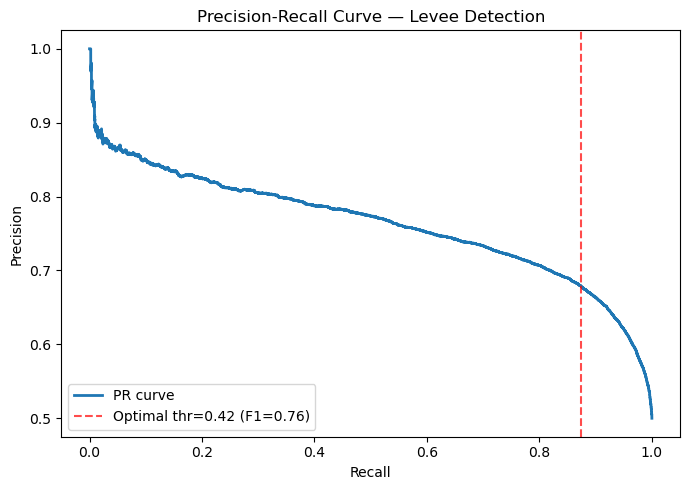

In [21]:
y_proba = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Optimal threshold: maximise F1
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
best_idx  = np.argmax(f1_scores[:-1])
best_thr  = float(thresholds[best_idx])
best_f1   = float(f1_scores[best_idx])

print(f'Optimal threshold : {best_thr:.3f}')
print(f'Best F1           : {best_f1:.3f}')
print(f'AP score          : {average_precision_score(y_test, y_proba):.3f}')
print(f'ROC-AUC           : {roc_auc_score(y_test, y_proba):.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, lw=2, label='PR curve')
ax.axvline(recall[best_idx], color='red', linestyle='--', alpha=0.7,
           label=f'Optimal thr={best_thr:.2f} (F1={best_f1:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Levee Detection')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'pr_curve.png', dpi=150)
plt.show()

### 6.2 Classification Report

In [22]:
y_pred = (y_proba >= best_thr).astype(int)
print(classification_report(
    y_test, y_pred,
    target_names=['non-levee', 'levee'],
    digits=3,
))

              precision    recall  f1-score   support

   non-levee      0.823     0.588     0.686     15000
       levee      0.679     0.874     0.764     15000

    accuracy                          0.731     30000
   macro avg      0.751     0.731     0.725     30000
weighted avg      0.751     0.731     0.725     30000



### 6.3 Feature Importance

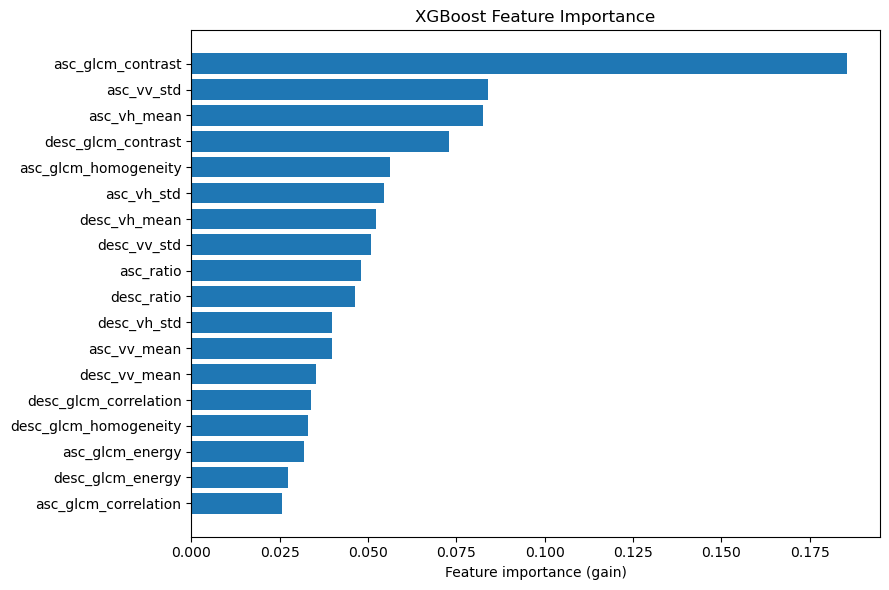

Feature importance ranking:
   1. asc_glcm_contrast                   0.1856
   2. asc_vv_std                          0.0840
   3. asc_vh_mean                         0.0824
   4. desc_glcm_contrast                  0.0729
   5. asc_glcm_homogeneity                0.0563
   6. asc_vh_std                          0.0546
   7. desc_vh_mean                        0.0523
   8. desc_vv_std                         0.0507
   9. asc_ratio                           0.0480
  10. desc_ratio                          0.0464
  11. desc_vh_std                         0.0398
  12. asc_vv_mean                         0.0398
  13. desc_vv_mean                        0.0352
  14. desc_glcm_correlation               0.0340
  15. desc_glcm_homogeneity               0.0331
  16. asc_glcm_energy                     0.0318
  17. desc_glcm_energy                    0.0275
  18. asc_glcm_correlation                0.0256


In [23]:
importance = model.feature_importances_
sorted_idx = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    [BAND_NAMES[i] for i in sorted_idx[::-1]],
    importance[sorted_idx[::-1]],
)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=150)
plt.show()

print('Feature importance ranking:')
for rank, i in enumerate(sorted_idx, 1):
    print(f'  {rank:2d}. {BAND_NAMES[i]:<35s} {importance[i]:.4f}')

---
## Section 7 — Save Model and Metadata

In [25]:
import json
from datetime import datetime
from sklearn.metrics import average_precision_score, roc_auc_score

model_path = OUT_DIR / 'xgb_levee_model.json'
booster = model.get_booster()
booster.save_model(str(model_path))
print(f'Model saved -> {model_path}')

metadata = {
    'created':            datetime.now().isoformat(),
    'model':              'XGBoostClassifier',
    'best_iteration':     int(model.best_iteration),
    'optimal_threshold':  best_thr,
    'best_f1':            best_f1,
    'ap_score':           float(average_precision_score(y_test, y_proba)),
    'roc_auc':            float(roc_auc_score(y_test, y_proba)),
    'band_names':         BAND_NAMES,
    'n_train':            int(len(X_train)),
    'n_test':             int(len(X_test)),
    'epsg':               EPSG,
    'pixel_size_m':       PIXEL_SIZE,
    'glcm_window':        GLCM_WINDOW,
    'glcm_levels':        GLCM_LEVELS,
    'levee_buffer_m':     LEVEE_BUFFER,
}

meta_path = OUT_DIR / 'model_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved -> {meta_path}')

print('\n=== Training complete ===')
print(f"  Threshold : {best_thr:.3f}")
print(f"  AP score  : {metadata['ap_score']:.3f}")
print(f"  ROC-AUC   : {metadata['roc_auc']:.3f}")

Model saved -> D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02\xgb_levee_model.json
Metadata saved -> D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02\model_metadata.json

=== Training complete ===
  Threshold : 0.416
  AP score  : 0.763
  ROC-AUC   : 0.800


---
## Section 8 — Full-AOI Inference & Map Export

Runs the trained XGBoost model across every pixel of the feature stack.
Processed in row-strips to keep memory bounded regardless of AOI size.

Outputs:
- `levee_probability.tif` — float32, per-pixel levee probability [0, 1]
- `levee_prediction.tif`  — uint8 binary map: 1=levee, 0=background, 255=nodata


In [26]:
# Config
INFERENCE_CHUNK_ROWS = 256   # rows per batch; reduce if RAM is tight

print('Reading feature stack metadata...')
ds_feat = gdal.Open(str(FEATURE_STACK_PATH), gdal.GA_ReadOnly)
if ds_feat is None:
    raise FileNotFoundError(f'Feature stack not found: {FEATURE_STACK_PATH}')

nrows_inf  = ds_feat.RasterYSize
ncols_inf  = ds_feat.RasterXSize
nbands_inf = ds_feat.RasterCount
gt_inf     = ds_feat.GetGeoTransform()
proj_inf   = ds_feat.GetProjection()
print(f'  Stack size  : {nrows_inf} x {ncols_inf} px  ({nbands_inf} bands)')
print(f'  Total pixels: {nrows_inf * ncols_inf:,}')

proba_map = np.full((nrows_inf, ncols_inf), np.nan, dtype=np.float32)

print(f'Running inference in strips of {INFERENCE_CHUNK_ROWS} rows...')
for row_start in range(0, nrows_inf, INFERENCE_CHUNK_ROWS):
    row_end      = min(row_start + INFERENCE_CHUNK_ROWS, nrows_inf)
    n_chunk_rows = row_end - row_start

    chunk = np.stack([
        ds_feat.GetRasterBand(b + 1).ReadAsArray(
            0, row_start, ncols_inf, n_chunk_rows
        ).astype(np.float32)
        for b in range(nbands_inf)
    ], axis=-1)

    flat  = chunk.reshape(-1, nbands_inf)
    valid = np.isfinite(flat).all(axis=1)

    if valid.any():
        proba_flat = np.full(len(flat), np.nan, dtype=np.float32)
        proba_flat[valid] = model.predict_proba(flat[valid])[:, 1]
        proba_map[row_start:row_end] = proba_flat.reshape(n_chunk_rows, ncols_inf)

    print(f'  Rows {row_end}/{nrows_inf}  '
          f'({row_end / nrows_inf * 100:.1f}%)  '
          f'valid in strip: {valid.sum():,}')

ds_feat = None
print()
print('Inference complete.')
print(f'  Valid pixels scored : {np.isfinite(proba_map).sum():,}')


Reading feature stack metadata...
  Stack size  : 27274 x 24994 px  (18 bands)
  Total pixels: 681,686,356
Running inference in strips of 256 rows...
  Rows 256/27274  (0.9%)  valid in strip: 6,398,464
  Rows 512/27274  (1.9%)  valid in strip: 6,398,464
  Rows 768/27274  (2.8%)  valid in strip: 6,398,464
  Rows 1024/27274  (3.8%)  valid in strip: 6,398,464
  Rows 1280/27274  (4.7%)  valid in strip: 6,398,464
  Rows 1536/27274  (5.6%)  valid in strip: 6,398,464
  Rows 1792/27274  (6.6%)  valid in strip: 6,398,464
  Rows 2048/27274  (7.5%)  valid in strip: 6,398,464
  Rows 2304/27274  (8.4%)  valid in strip: 6,398,464
  Rows 2560/27274  (9.4%)  valid in strip: 6,398,464
  Rows 2816/27274  (10.3%)  valid in strip: 6,398,464
  Rows 3072/27274  (11.3%)  valid in strip: 6,398,464
  Rows 3328/27274  (12.2%)  valid in strip: 6,398,464
  Rows 3584/27274  (13.1%)  valid in strip: 6,398,464
  Rows 3840/27274  (14.1%)  valid in strip: 6,398,464
  Rows 4096/27274  (15.0%)  valid in strip: 6,398,464

In [29]:
geo_info_inf = {
    'geotransform': gt_inf,
    'projection':   proj_inf,
    'nrows':        nrows_inf,
    'ncols':        ncols_inf,
}

# Probability map (float32)
proba_path = OUT_DIR / 'levee_probability.tif'
write_multiband_tiff(
    path=proba_path,
    arrays=[proba_map],
    band_names=['levee_probability'],
    geo_info=geo_info_inf,
    nodata=-9999.0,
)

# Binary prediction map (uint8): 0=background, 1=levee, 255=nodata
pred_map = np.where(
    np.isnan(proba_map),
    np.uint8(255),
    (proba_map >= best_thr).astype(np.uint8),
)

pred_path = OUT_DIR / 'levee_prediction.tif'
ds_pred = gdal.GetDriverByName('GTiff').Create(
    str(pred_path), ncols_inf, nrows_inf, 1, gdal.GDT_Byte,
    options=['COMPRESS=LZW', 'PREDICTOR=2', 'NUM_THREADS=ALL_CPUS',
             'BIGTIFF=IF_SAFER', 'TILED=YES'],
)
ds_pred.SetGeoTransform(gt_inf)
ds_pred.SetProjection(proj_inf)
b_pred = ds_pred.GetRasterBand(1)
b_pred.WriteArray(pred_map)
b_pred.SetNoDataValue(255)
b_pred.SetDescription('levee_prediction')
ds_pred.FlushCache()
ds_pred = None

n_levee = int((pred_map == 1).sum())
print(f'Binary prediction map -> {pred_path}')
print(f'  Threshold   : {best_thr:.3f}')
print(f'  Levee pixels: {n_levee:,}')
print(f'  Levee area  : {n_levee * PIXEL_SIZE**2 / 1e6:.2f} km²')
print(f'  Probability map -> {proba_path}')
print()
print('Load both GeoTIFFs in QGIS:')
print('  levee_probability.tif — Singleband pseudocolor (0–1)')
print('  levee_prediction.tif  — Paletted (0=background, 1=levee)')


  Writing band 1/1: levee_probability  (0 remaining)
  Saved: levee_probability.tif  (1 bands, 27274x24994)
Binary prediction map -> D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02\levee_prediction.tif
  Threshold   : 0.416
  Levee pixels: 53,210,374
  Levee area  : 5321.04 km²
  Probability map -> D:\90_PersonalFoldlers\JZa\DataProcessing\levees_detection\sentinel\02_modeldevelopment\v02\levee_probability.tif

Load both GeoTIFFs in QGIS:
  levee_probability.tif — Singleband pseudocolor (0–1)
  levee_prediction.tif  — Paletted (0=background, 1=levee)
